C:\Users\popeye\AppData\Local\Temp\ipykernel_76560\2748426946.py:102: UserWarning: Glyph 192 (\N{LATIN CAPITAL LETTER A WITH GRAVE}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\popeye\AppData\Local\Temp\ipykernel_76560\2748426946.py:102: UserWarning: Glyph 240 (\N{LATIN SMALL LETTER ETH}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\popeye\anaconda3\envs\pattern_recognition\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 192 (\N{LATIN CAPITAL LETTER A WITH GRAVE}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\popeye\anaconda3\envs\pattern_recognition\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 240 (\N{LATIN SMALL LETTER ETH}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


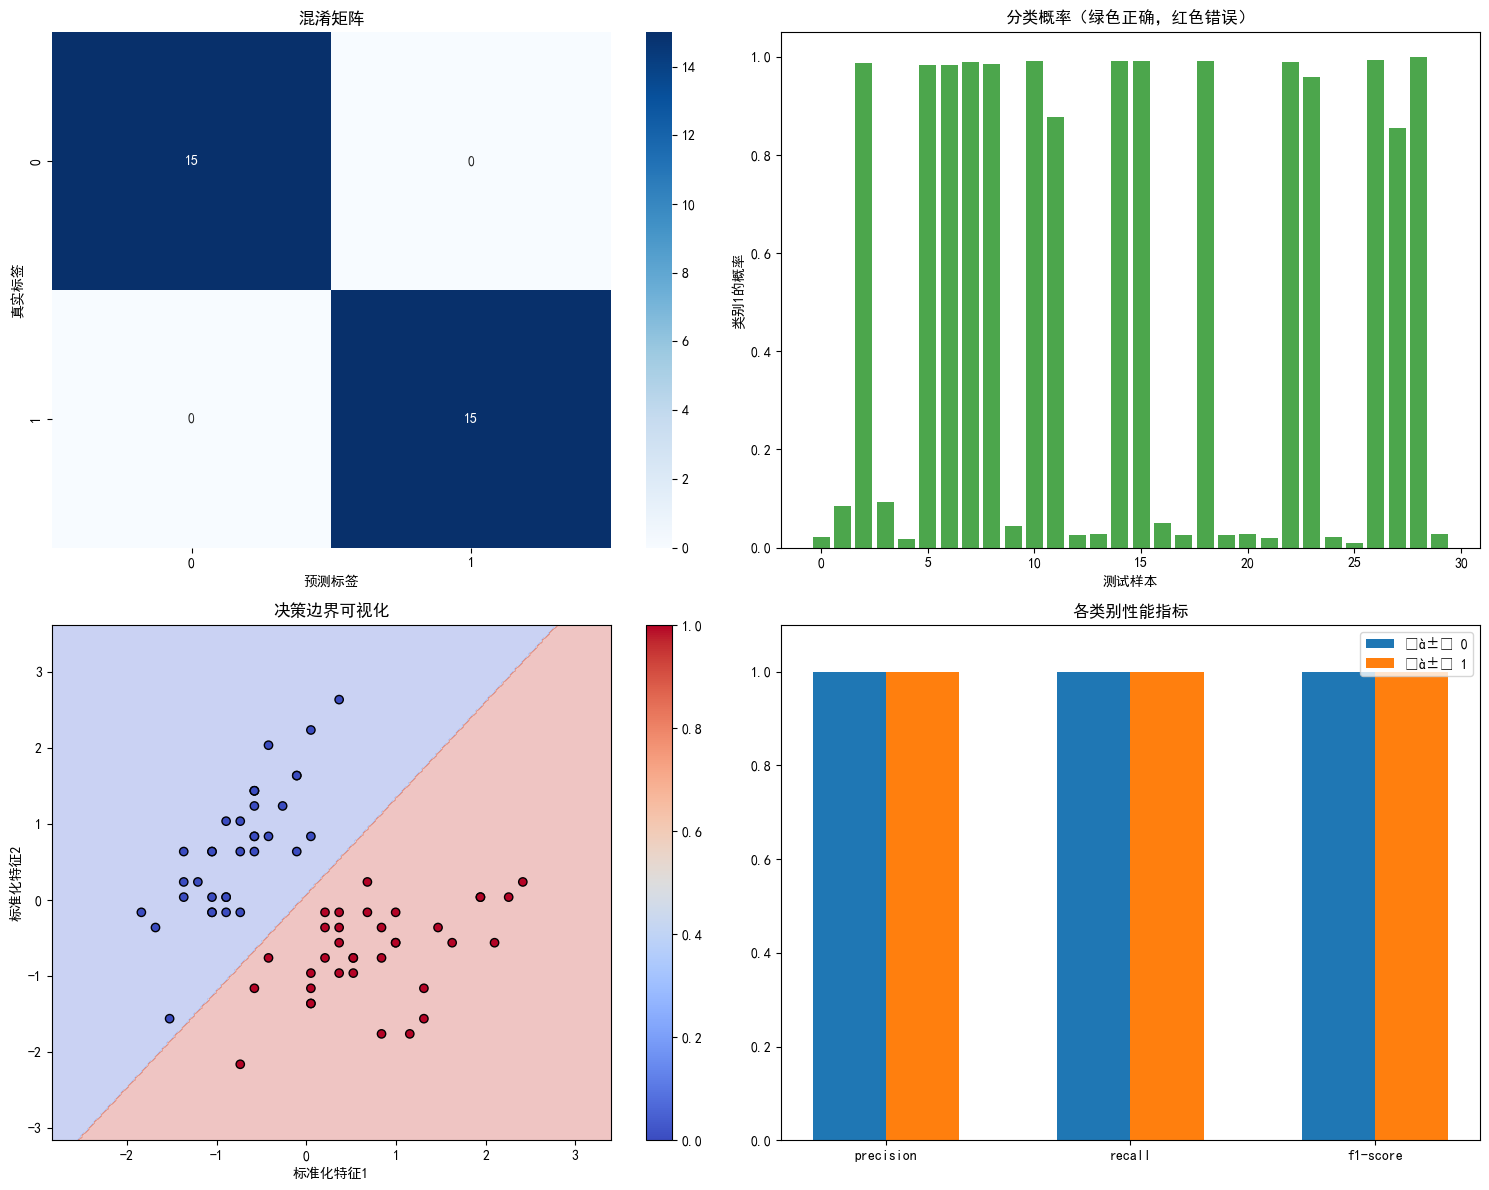

完整决策系统总结：
数据预处理：标准化特征
模型选择：线性SVM，提供概率输出
决策机制：基于概率的贝叶斯决策
评估验证：多角度性能分析


In [4]:
# %load 6-6.py
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # ÉèÖÃÄ¬ÈÏ×ÖÌåÎªºÚÌå
plt.rcParams['axes.unicode_minus'] = False
#from sklearn.datasets import make_circles
#from sklearn.svm import SVC
def complete_decision_system():
    """
    ÍêÕûµÄ¾ö²ßÏµÍ³£º´ÓÊý¾Ýµ½¾ö²ß
    """
    from sklearn.datasets import load_iris
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from sklearn.svm import SVC
    from sklearn.metrics import classification_report, confusion_matrix
    import seaborn as sns
    
    # 1. Êý¾Ý×¼±¸
    iris = load_iris()
    X, y = iris.data, iris.target
    
    # Ö»Ê¹ÓÃÁ½¸öÀà±ð¼ò»¯ÎÊÌâ
    X = X[y != 2]
    y = y[y != 2]
    
    # ·Ö¸îÊý¾Ý
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # 2. ÌØÕ÷±ê×¼»¯
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 3. Ä£ÐÍÑµÁ·£¨´ø¸ÅÂÊÊä³ö£©
    model = SVC(kernel='linear', probability=True, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    # 4. ¾ö²ßÓëÆÀ¹À
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)
    
    # 5. ¿ÉÊÓ»¯½á¹û
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 5.1 »ìÏý¾ØÕó
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
    axes[0, 0].set_title('混淆矩阵')
    axes[0, 0].set_xlabel('预测标签')
    axes[0, 0].set_ylabel('真实标签')
    
    # 5.2 ¸ÅÂÊ·Ö²¼
    for i in range(len(y_test)):
        color = 'green' if y_pred[i] == y_test[i] else 'red'
        axes[0, 1].bar([i], y_prob[i, 1], color=color, alpha=0.7)
    axes[0, 1].set_title('分类概率（绿色正确，红色错误）')
    axes[0, 1].set_xlabel('测试样本')
    axes[0, 1].set_ylabel('类别1的概率')
    
    # 5.3 ¾ö²ß±ß½ç
    # Ê¹ÓÃÇ°Á½¸öÌØÕ÷¿ÉÊÓ»¯¾ö²ß±ß½ç
    X_2d = X_train_scaled[:, :2]
    model_2d = SVC(kernel='linear', probability=True)
    model_2d.fit(X_2d, y_train)
    
    # ´´½¨Íø¸ñ
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    axes[1, 0].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    scatter = axes[1, 0].scatter(X_2d[:, 0], X_2d[:, 1], c=y_train, 
                                cmap=plt.cm.coolwarm, edgecolors='k')
    axes[1, 0].set_title('决策边界可视化')
    axes[1, 0].set_xlabel('标准化特征1')
    axes[1, 0].set_ylabel('标准化特征2')
    plt.colorbar(scatter, ax=axes[1, 0])
    
    # 5.4 ÐÔÄÜÖ¸±ê
    report = classification_report(y_test, y_pred, output_dict=True)
    metrics = ['precision', 'recall', 'f1-score']
    classes = ['0', '1']
    
    for i, cls in enumerate(classes):
        values = [report[cls][metric] for metric in metrics]
        axes[1, 1].bar(np.arange(len(metrics)) + i*0.3, values, 
                      width=0.3, label=f'Àà±ð {cls}')
    
    axes[1, 1].set_title('各类别性能指标')
    axes[1, 1].set_xticks(np.arange(len(metrics)) + 0.15)
    axes[1, 1].set_xticklabels(metrics)
    axes[1, 1].legend()
    axes[1, 1].set_ylim(0, 1.1)
    
    plt.tight_layout()
    plt.show()
    
    print("完整决策系统总结：")
    print("数据预处理：标准化特征")
    print("模型选择：线性SVM，提供概率输出")  
    print("决策机制：基于概率的贝叶斯决策")
    print("评估验证：多角度性能分析")
    
    return model, scaler, report

# ÔËÐÐÍêÕûÏµÍ³
final_model, feature_scaler, performance_report = complete_decision_system()